Используйте датасет Credit Card Default Prediction (предсказание дефолта по кредитной карте), доступный по ссылке:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

Целевая переменная: default.payment.next.month (дефолт в следующем месяце).
Признаки: демографические данные, история платежей, сумма кредита и др.



In [1]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print(f"Путь к датасету: {path}")


import os
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            break

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Путь к датасету: /kaggle/input/default-of-credit-card-clients-dataset


Задача 1. Подготовка данных и базовое моделирование (1 балла)
- Загрузите датасет, разделите на обучающую и тестовую выборки (80/20).

- Обучите модель CatBoostClassifier с параметрами по умолчанию.

- Оцените качество модели с помощью ROC-AUC на тесте.

In [2]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


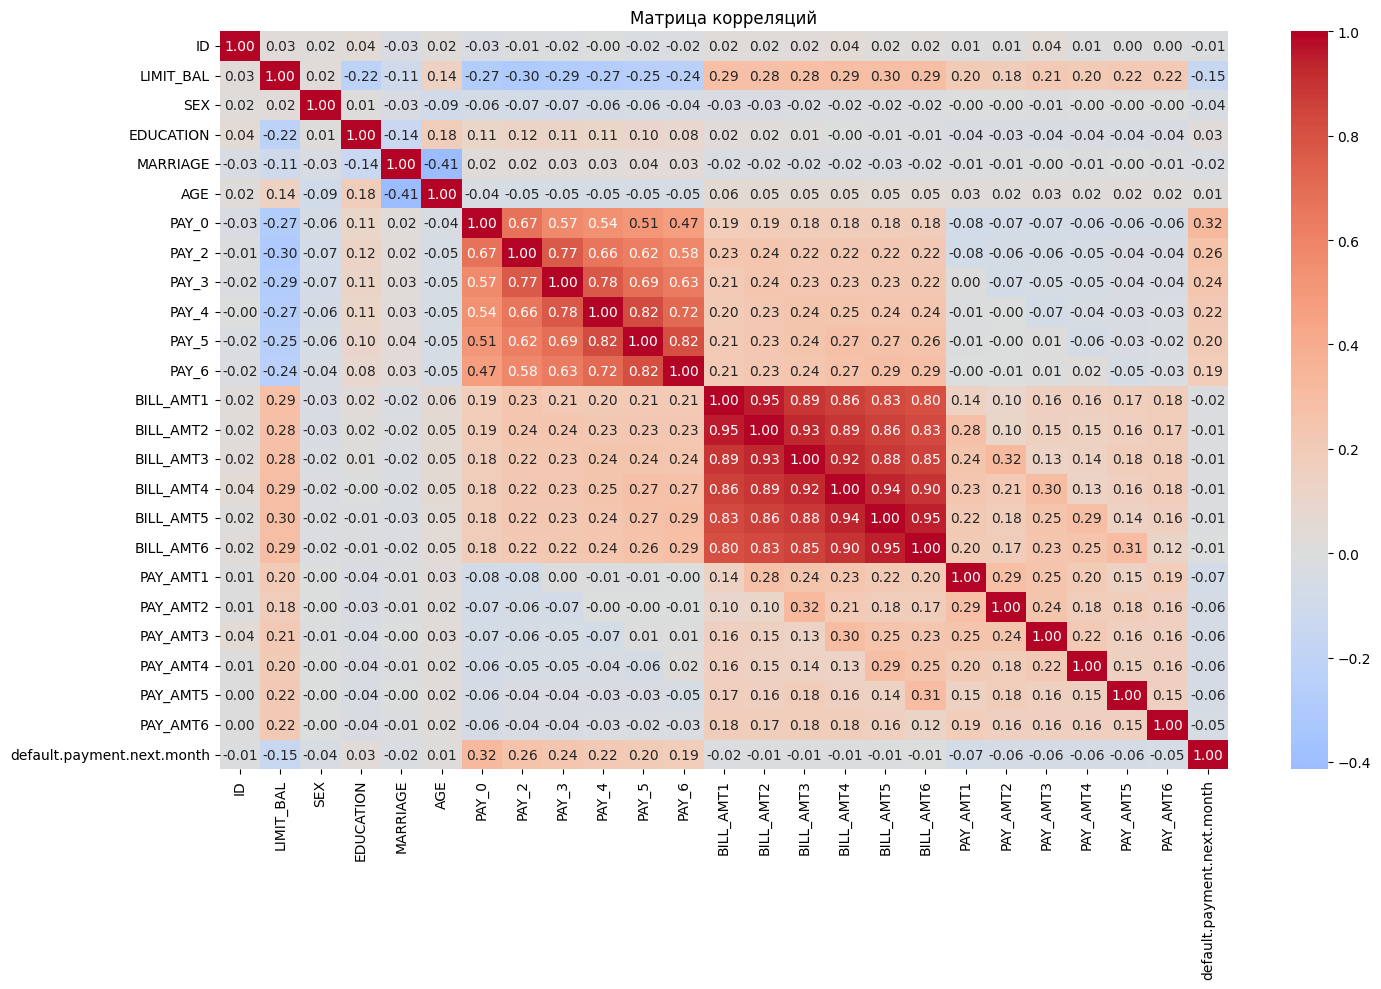

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['default.payment.next.month']), df['default.payment.next.month'],
                                                    test_size=0.2, random_state=42, stratify=df['default.payment.next.month'])
X_train.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
22788,22789,160000.0,2,2,2,33,2,2,3,2,...,168541.0,164310.0,162681.0,163005.0,15000.0,0.0,0.0,6100.0,12300.0,6100.0
29006,29007,150000.0,2,1,2,34,1,-1,-1,-2,...,0.0,0.0,0.0,0.0,53.0,0.0,0.0,0.0,0.0,0.0
16950,16951,10000.0,1,2,1,50,1,2,0,0,...,8446.0,8067.0,8227.0,8400.0,2.0,1281.0,1134.0,294.0,305.0,1000.0
22280,22281,220000.0,2,1,2,29,0,0,0,0,...,215139.0,218513.0,131660.0,134346.0,9100.0,9000.0,7887.0,4800.0,4900.0,6000.0
11346,11347,310000.0,2,1,2,32,1,-2,-1,0,...,326.0,326.0,-235.0,-235.0,0.0,326.0,0.0,0.0,0.0,1200.0


In [7]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


In [10]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score

model = CatBoostClassifier(random_seed=42, verbose=100)
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print('ROC-AUC', roc_auc)

Learning rate set to 0.040021
0:	learn: 0.6707186	total: 37.4ms	remaining: 37.4s
100:	learn: 0.4186212	total: 2.23s	remaining: 19.9s
200:	learn: 0.4075246	total: 4.19s	remaining: 16.7s
300:	learn: 0.3976786	total: 5.34s	remaining: 12.4s
400:	learn: 0.3882738	total: 6.53s	remaining: 9.76s
500:	learn: 0.3794445	total: 7.68s	remaining: 7.65s
600:	learn: 0.3711615	total: 8.81s	remaining: 5.85s
700:	learn: 0.3627133	total: 10.3s	remaining: 4.4s
800:	learn: 0.3552934	total: 12.7s	remaining: 3.14s
900:	learn: 0.3476411	total: 13.8s	remaining: 1.52s
999:	learn: 0.3404923	total: 15s	remaining: 0us
ROC-AUC 0.7771136631075503


Задача 2. Оценка важности признаков (2 балла)
- Встроенная важность CatBoost (PredictionValuesChange) используйте get_feature_importance() для получения важности признаков, основанной на изменении предсказаний.

- Permutation Importance,используйте sklearn.inspection.permutation_importance. Постройте боксплот важности признаков.

- SHAP-анализ, используйте SHAP-значения для тестовой выборки.Постройте summary plot (bar и dot). Выберите одно наблюдение и объясните его предсказание с помощью shap.force_plot

Важно! Вычисляйте важность на обучающей или валидационной выборке, но не на тестовой. Тестовая выборка используется только для финальной оценки модели.

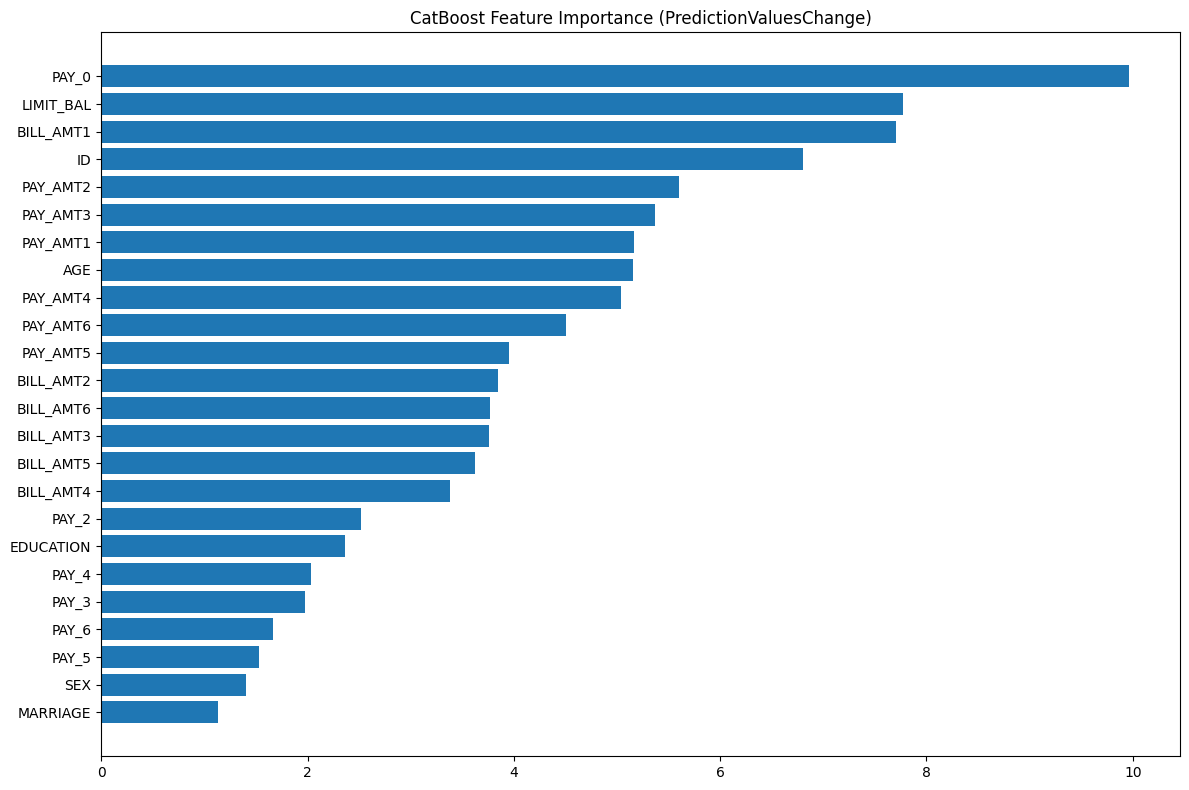

In [23]:
cat_importances = model.get_feature_importance(Pool(X_train, y_train), type='PredictionValuesChange')
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': cat_importances}).sort_values('importance', ascending=True)
plt.figure(figsize=(12, 8))
plt.title("CatBoost Feature Importance (PredictionValuesChange)")
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.tight_layout()
plt.show()

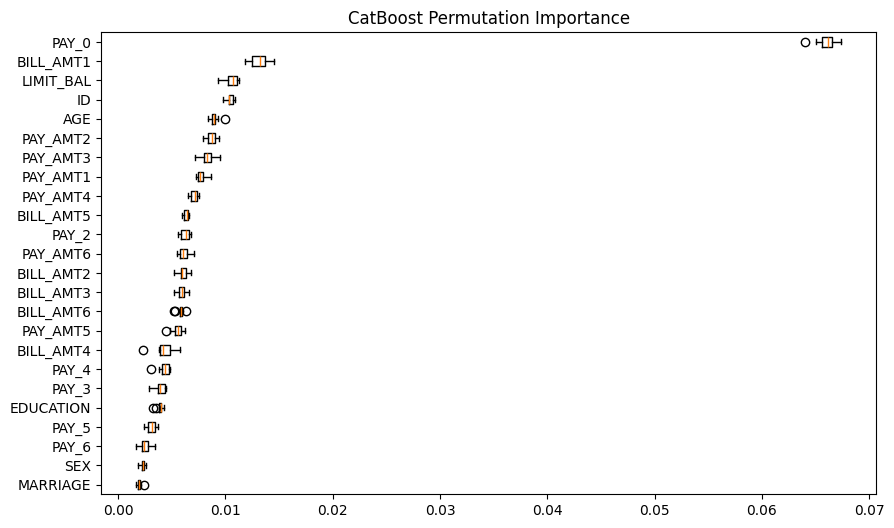

In [24]:
from sklearn.inspection import permutation_importance

cat_result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
plt.figure(figsize=(10, 6))
plt.title("CatBoost Permutation Importance")
sorted_idx = cat_result.importances_mean.argsort()
plt.boxplot(cat_result.importances[sorted_idx].T, vert=False, tick_labels=X_train.columns[sorted_idx])
plt.show()

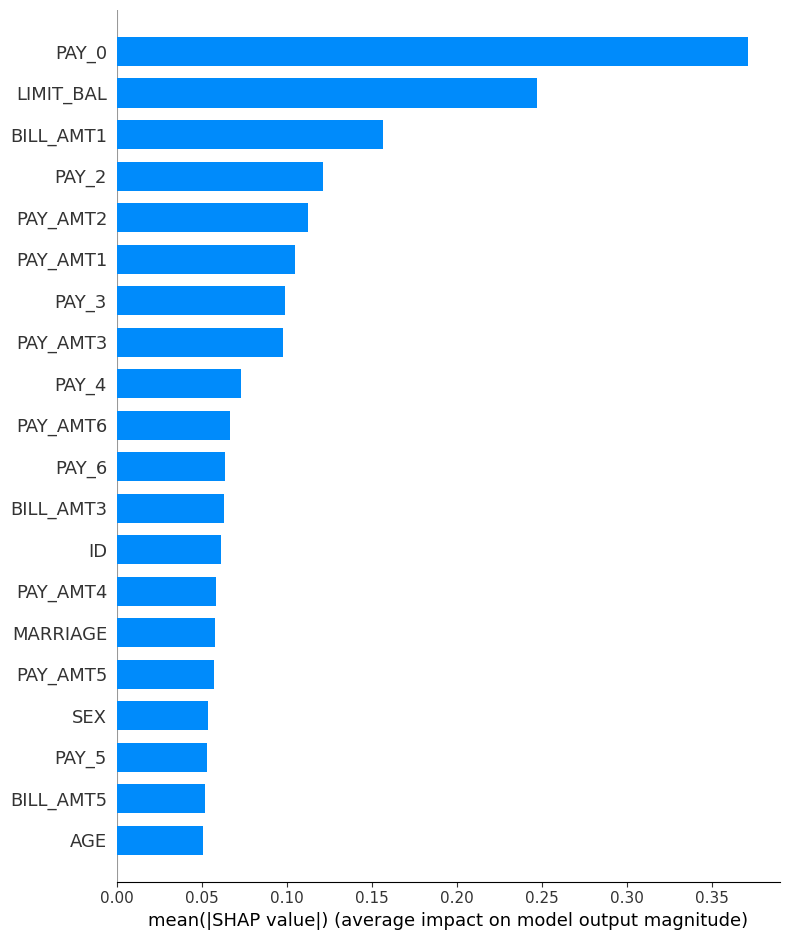

In [26]:
import shap

cat_importances = model.get_feature_importance(Pool(X_train, y_train), type = 'ShapValues')

shap.summary_plot(cat_importances[:,:-1], X_train, plot_type="bar", feature_names=X_train.columns)

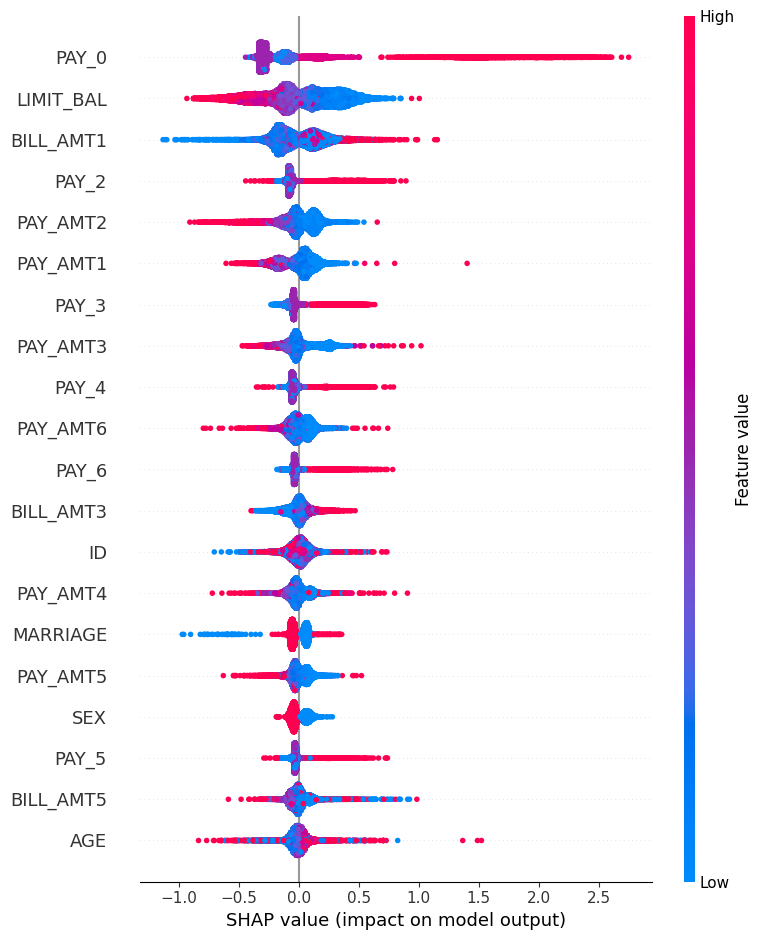

In [27]:
shap.summary_plot(cat_importances[:,:-1], X_train, plot_type="dot", feature_names=X_train.columns)

In [28]:
observation_index = 2
observation_shap = cat_importances[observation_index]

In [29]:
observation_shap

array([ 0.11540713,  0.39010955,  0.08465971,  0.06735835,  0.02752581,
        0.00905809,  0.05479105,  0.47145071, -0.02411397, -0.0462422 ,
       -0.03406335, -0.0519998 , -0.1186558 , -0.05288519, -0.00393602,
       -0.04293609, -0.01751487, -0.03203206,  0.13567133,  0.10640644,
       -0.0849388 ,  0.03432105,  0.08399177, -0.04735695, -1.6050913 ])

In [31]:
shap.initjs()

In [34]:
shap.force_plot(shap.Explanation(values=observation_shap[:-1],
                                 base_values=observation_shap[-1],
                                 data=X_train.iloc[observation_index],
                                 feature_names=X_train.columns))

Задача 3. Выводы (1 балла)
- Сравните топ-5 важных признаков по каждому методу.

- Найдите признаки, которые важны во всех методах;важны только в одном методе; имеют отрицательную важность в Permutation Importance.

- Объясните, почему методы могут давать разные результаты.

In [47]:
import numpy as np

fi_5 = feature_importance_df.tail(5)["feature"].tolist()
pi_5 = X_train.columns[np.argsort(cat_result.importances_mean)[-5:]].tolist()
shap_val = cat_importances[:,:-1]
sh_5 = X_train.columns[np.argsort(np.abs(shap_val).mean(axis=0))[-5:]].tolist()
print('FI_top_5', fi_5)
print('PI_top_5', pi_5)
print('SH_top_5', sh_5)

fi_set, pi_set, sh_set = set(fi_5), set(pi_5), set(sh_5)
print("Важные признаки везде:", list(fi_set & pi_set & sh_set))
print("Важные признаки только в fi:", list(fi_set - (pi_set | sh_set)))
print("Важные признаки только в pi:", list(pi_set - (fi_set | sh_set)))
print("Важные признаки только в sh:", list(sh_set - (pi_set | fi_set)))
neg = X_train.columns[cat_result.importances_mean < 0].tolist()
print(neg)

FI_top_5 ['PAY_AMT2', 'ID', 'BILL_AMT1', 'LIMIT_BAL', 'PAY_0']
PI_top_5 ['AGE', 'ID', 'LIMIT_BAL', 'BILL_AMT1', 'PAY_0']
SH_top_5 ['PAY_AMT2', 'PAY_2', 'BILL_AMT1', 'LIMIT_BAL', 'PAY_0']
Важные признаки везде: ['LIMIT_BAL', 'BILL_AMT1', 'PAY_0']
Важные признаки только в fi: []
Важные признаки только в pi: ['AGE']
Важные признаки только в sh: ['PAY_2']
[]


Ответ:  
разные результаты получаютсся из-за того, что у разных методов разные цели, у каждого свои изменяемые параметры, одни методы лучше видят одни зависимости, другие их не видят. В целом видно, что общие признаки присутствуют.

Задача 4. Отбор признаков (2 балла)

- Определите порог важности (например, важность случайного признака) и удалите менее важные признаки.

- Обучите модель на сокращённом наборе признаков и сравните ROC-AUC с исходной моделью.

- Можно ли сократить количество признаков без потери качества?

In [50]:
X_train_random = X_train.copy()
X_train_random['random_feature'] = np.random.randn(len(X_train))

model_random = CatBoostClassifier(random_seed=42, verbose=0)
model_random.fit(X_train_random, y_train)
threshold = model_random.get_feature_importance(Pool(X_train_random, y_train), type='PredictionValuesChange')[-1]
print('threshold: ', threshold)
important_features = feature_importance_df[feature_importance_df['importance'] > threshold]['feature'].tolist()
print(f"{len(important_features)} из {len(X_train.columns)}")

threshold:  5.816569747206863
4 из 24


In [51]:
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]

model = CatBoostClassifier(random_seed=42, verbose=100)
model.fit(X_train_important, y_train)
y_pred_proba = model.predict_proba(X_test_important)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print('ROC-AUC', roc_auc)

Learning rate set to 0.040021
0:	learn: 0.6711311	total: 8.84ms	remaining: 8.84s
100:	learn: 0.4329680	total: 893ms	remaining: 7.95s
200:	learn: 0.4274503	total: 2.95s	remaining: 11.7s
300:	learn: 0.4224839	total: 4.08s	remaining: 9.48s
400:	learn: 0.4176892	total: 4.84s	remaining: 7.23s
500:	learn: 0.4133471	total: 5.63s	remaining: 5.61s
600:	learn: 0.4094313	total: 6.42s	remaining: 4.26s
700:	learn: 0.4056494	total: 7.21s	remaining: 3.07s
800:	learn: 0.4018535	total: 8.01s	remaining: 1.99s
900:	learn: 0.3983631	total: 8.87s	remaining: 974ms
999:	learn: 0.3948900	total: 9.66s	remaining: 0us
ROC-AUC 0.7491314806748705


Ответ:  
сильно сократить число признаков нельзя без потери качества не получится. В данном случае качество упало не очень сильно, но все равно упало. если бы мы убрали меньшее количество столбцов, оставив важные по мнению других методов, то,скорее всего, получилось бы не так сильно уронить качество.

Задача 5. Анализ с добавленными случайными признаками (4 балла)

- Добавьте 10 случайных нормально распределенных признаков в датасет.

- Выполните оценку важности признаков (как в задаче 2) и проанализируйте, как методы ранжируют случайные признаки.

- Выполните отбор признаков с разными порогами 0%, 25%, 50%, 75% наименее важных признаков (удаляйте).

- Для каждого порога обучите модель и оцените ROC-AUC на тесте.

- Постройте график зависимости ROC-AUC от количества удаленных признаков.

- Проанализируйте, как изменяется качество модели при удалении разных долей признаков.


In [53]:
X_train_random2 = X_train.copy()
for i in range(10):
  X_train_random2[f'random_feature_{i}'] = np.random.randn(len(X_train))

model_random = CatBoostClassifier(random_seed=42, verbose=0)
model_random.fit(X_train_random2, y_train)
X_train_random2.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,random_feature_0,random_feature_1,random_feature_2,random_feature_3,random_feature_4,random_feature_5,random_feature_6,random_feature_7,random_feature_8,random_feature_9
22788,22789,160000.0,2,2,2,33,2,2,3,2,...,-0.687652,-1.347931,-0.397931,0.729179,0.295828,-0.271498,1.829531,0.484887,0.711810,-1.360108
29006,29007,150000.0,2,1,2,34,1,-1,-1,-2,...,-0.690176,0.758628,-0.987657,-1.596377,0.414854,-0.876630,0.201218,-0.945762,0.155967,0.564676
16950,16951,10000.0,1,2,1,50,1,2,0,0,...,-0.753545,1.956208,-0.123275,1.902528,1.290737,-1.075522,-0.600400,1.861389,0.240949,0.360445
22280,22281,220000.0,2,1,2,29,0,0,0,0,...,1.333369,-2.607354,-0.569288,1.082674,0.780205,-2.641489,0.934698,-0.954723,0.785258,-0.939577
11346,11347,310000.0,2,1,2,32,1,-2,-1,0,...,-1.232094,-0.354071,-0.245627,0.737382,-2.012054,-0.999273,-0.421171,2.330485,-1.312883,-1.953401


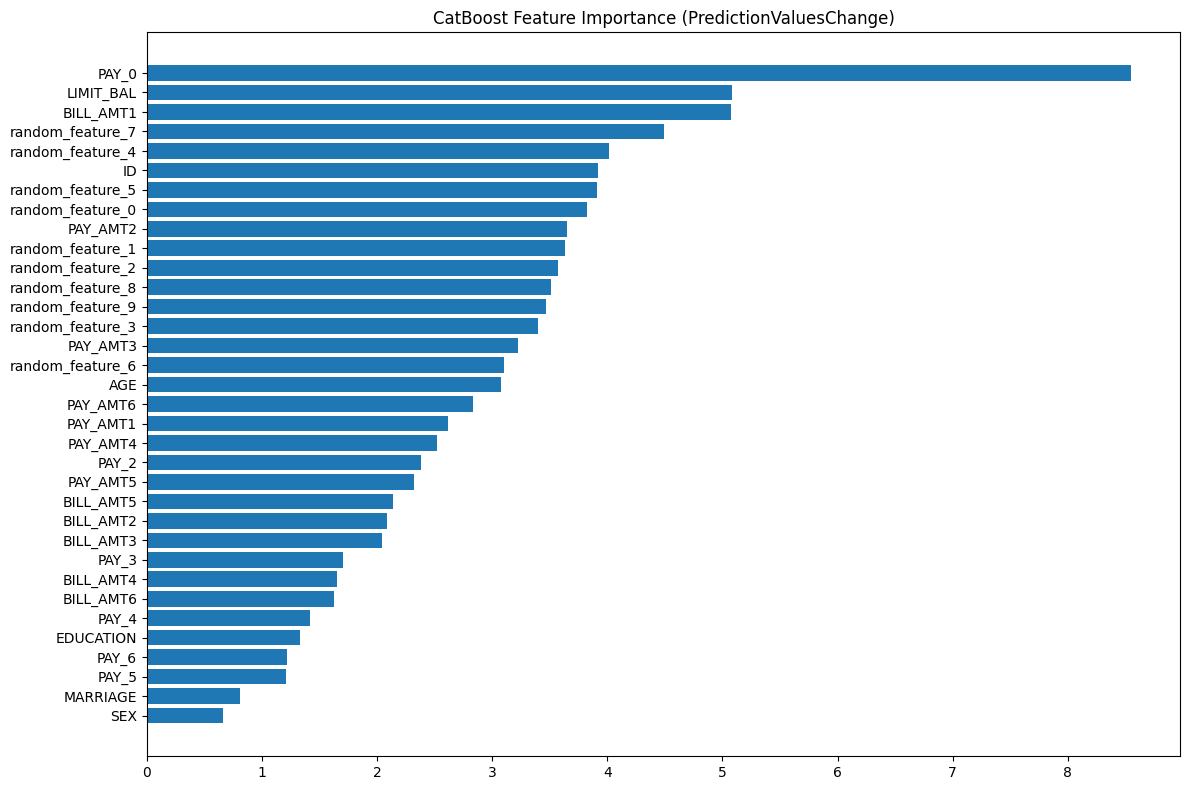

In [55]:
cat_importances = model_random.get_feature_importance(Pool(X_train_random2, y_train), type='PredictionValuesChange')
feature_importance_df = pd.DataFrame({'feature': X_train_random2.columns, 'importance': cat_importances}).sort_values('importance', ascending=True)
plt.figure(figsize=(12, 8))
plt.title("CatBoost Feature Importance (PredictionValuesChange)")
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.tight_layout()
plt.show()

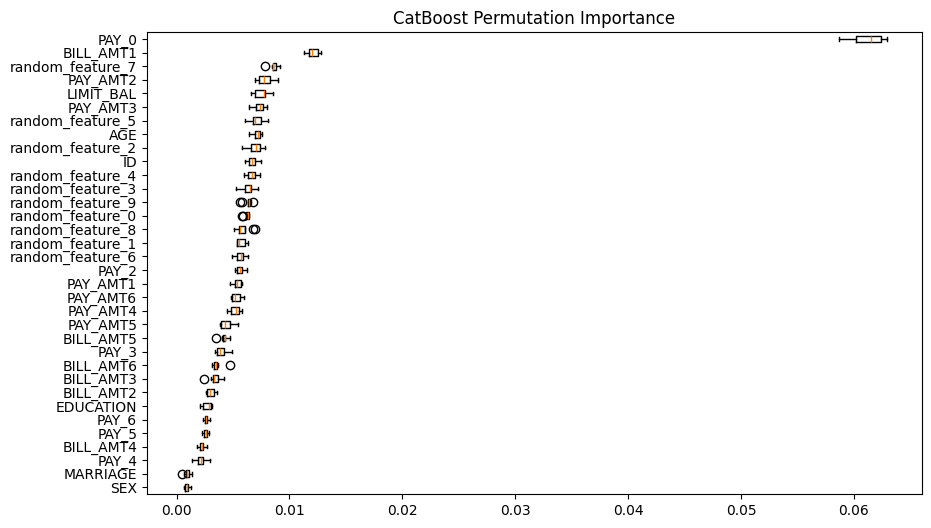

In [56]:
cat_result = permutation_importance(model_random, X_train_random2, y_train, n_repeats=10, random_state=42)
plt.figure(figsize=(10, 6))
plt.title("CatBoost Permutation Importance")
sorted_idx = cat_result.importances_mean.argsort()
plt.boxplot(cat_result.importances[sorted_idx].T, vert=False, tick_labels=X_train_random2.columns[sorted_idx])
plt.show()

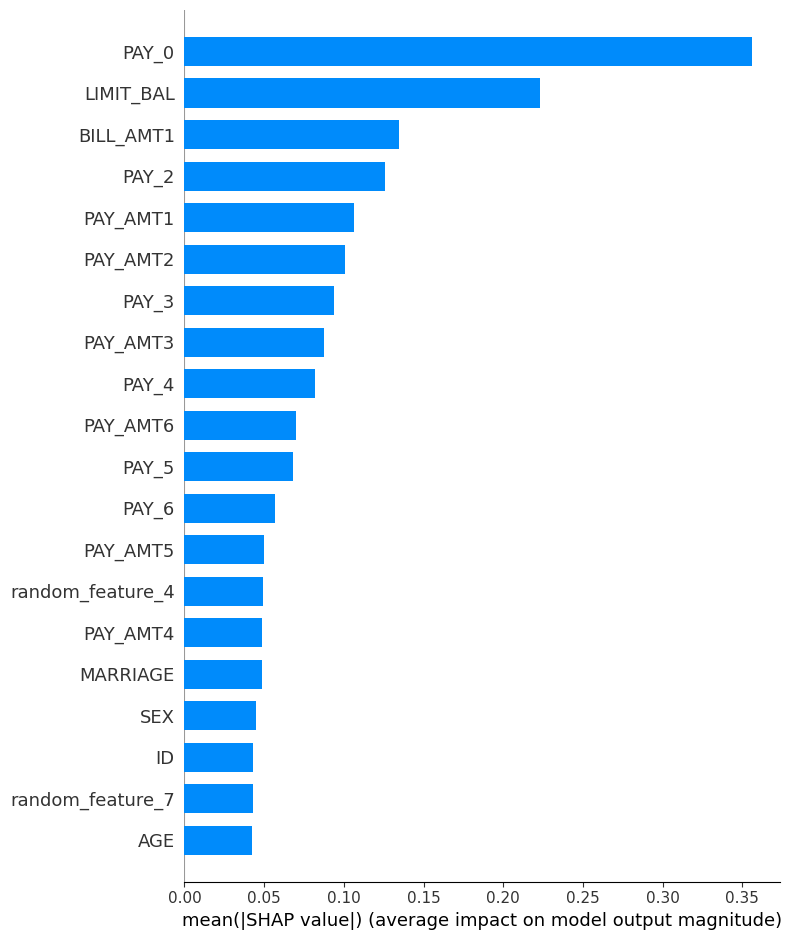

In [57]:
cat_importances = model_random.get_feature_importance(Pool(X_train_random2, y_train), type = 'ShapValues')

shap.summary_plot(cat_importances[:,:-1], X_train_random2, plot_type="bar", feature_names=X_train_random2.columns)

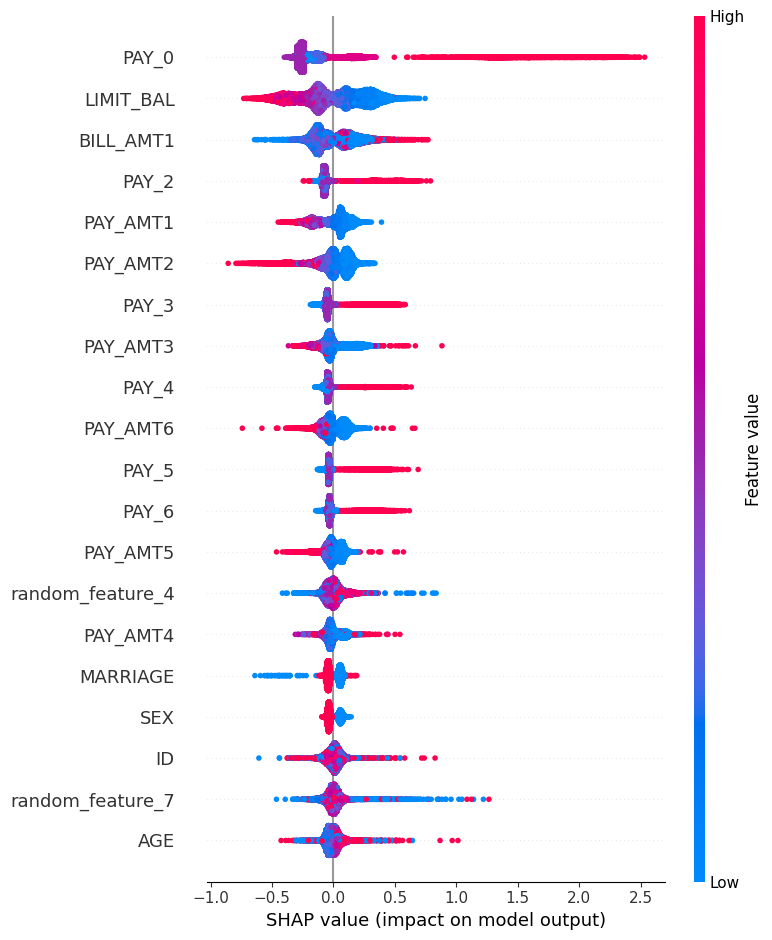

In [58]:
cat_importances = model_random.get_feature_importance(Pool(X_train_random2, y_train), type = 'ShapValues')

shap.summary_plot(cat_importances[:,:-1], X_train_random2, plot_type="dot", feature_names=X_train_random2.columns)

Вывод:  
FI сильно повелся на рандомные признаки, до топ-5 добрались 2 случайных признака. Седьмой случайный признак посчитал важным и PI. А вот SHAP не увидел в случаных признаках важности, как и должно быть.

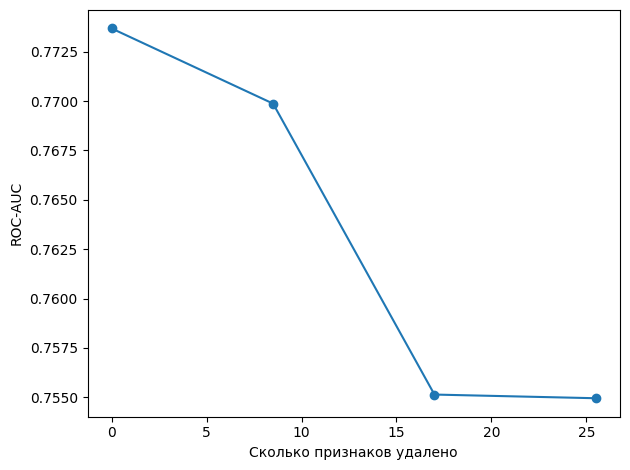

In [64]:
X_test_random2 = X_test.copy()
for i in range(10):
  X_test_random2[f'random_feature_{i}'] = np.random.randn(len(X_test))

fi_order = feature_importance_df["feature"].tolist()
parts = [0, 0.25, 0.50, 0.75]
removed, aucs = [], []

for part in parts:
  c = fi_order[int(part * len(fi_order)):]
  model = CatBoostClassifier(random_seed=42, verbose=0).fit(X_train_random2[c], y_train)
  auc = roc_auc_score(y_test, model.predict_proba(X_test_random2[c])[:, 1])
  removed.append(part * len(fi_order))
  aucs.append(auc)

plt.plot(removed, aucs, marker="o")
plt.xlabel("Сколько признаков удалено")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

Вывод:  
По графику видно, что качество все время падает, но когда удалено 25% признаков, то качество падает совсем немного, не сильно страшно. В то же время удаление 75% признаков практически не отличается от удаления 100%.